## Modeling with K-Nearest Neighbors Ball Tree Algorithm for Red Wine Quality Prediction (Classification Problem)

In [860]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report


In [861]:
redwine_df = pd.read_csv('../winequality-red-clean.csv', sep=',')
redwine_df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1365,7.3,0.585,0.18,2.4,0.078,15.0,60.0,0.99638,3.31,0.54,9.8,5
1331,6.8,0.590,0.10,1.7,0.063,34.0,53.0,0.99580,3.41,0.67,9.7,5
10,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.99590,3.28,0.54,9.2,5
435,9.3,0.775,0.27,2.8,0.078,24.0,56.0,0.99840,3.31,0.67,10.6,6
857,8.3,0.280,0.48,2.1,0.093,6.0,12.0,0.99408,3.26,0.62,12.4,7


In [862]:
redwine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1458 non-null   float64
 1   volatile acidity      1458 non-null   float64
 2   citric acid           1458 non-null   float64
 3   residual sugar        1458 non-null   float64
 4   chlorides             1458 non-null   float64
 5   free sulfur dioxide   1458 non-null   float64
 6   total sulfur dioxide  1458 non-null   float64
 7   density               1458 non-null   float64
 8   pH                    1458 non-null   float64
 9   sulphates             1458 non-null   float64
 10  alcohol               1458 non-null   float64
 11  quality               1458 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 136.8 KB


# Simple Descriptive Analysis

In [863]:
redwine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,8.312209,0.524155,0.265281,2.388717,0.081580,15.089849,43.662209,0.996718,3.316276,0.642414,10.416975,5.646776
std,1.647586,0.169595,0.191271,0.865307,0.021298,9.317669,29.414125,0.001718,0.141196,0.129753,1.020614,0.801119
min,5.000000,0.120000,0.000000,1.200000,0.038000,1.000000,6.000000,0.991500,2.880000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995600,3.220000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,36.000000,0.996700,3.315000,0.620000,10.200000,6.000000
75%,9.200000,0.635000,0.420000,2.600000,0.089000,21.000000,58.000000,0.997800,3.400000,0.720000,11.100000,6.000000
max,13.500000,1.040000,0.790000,6.700000,0.226000,47.000000,145.000000,1.002200,3.750000,1.160000,13.600000,8.000000


### the scater plot of the data below, describes the relationship between the density and alcohol content of the red wine.
the data shows that the density of the red wine is inversely proportional to the alcohol content. The higher the alcohol content, the lower the density of the red wine.

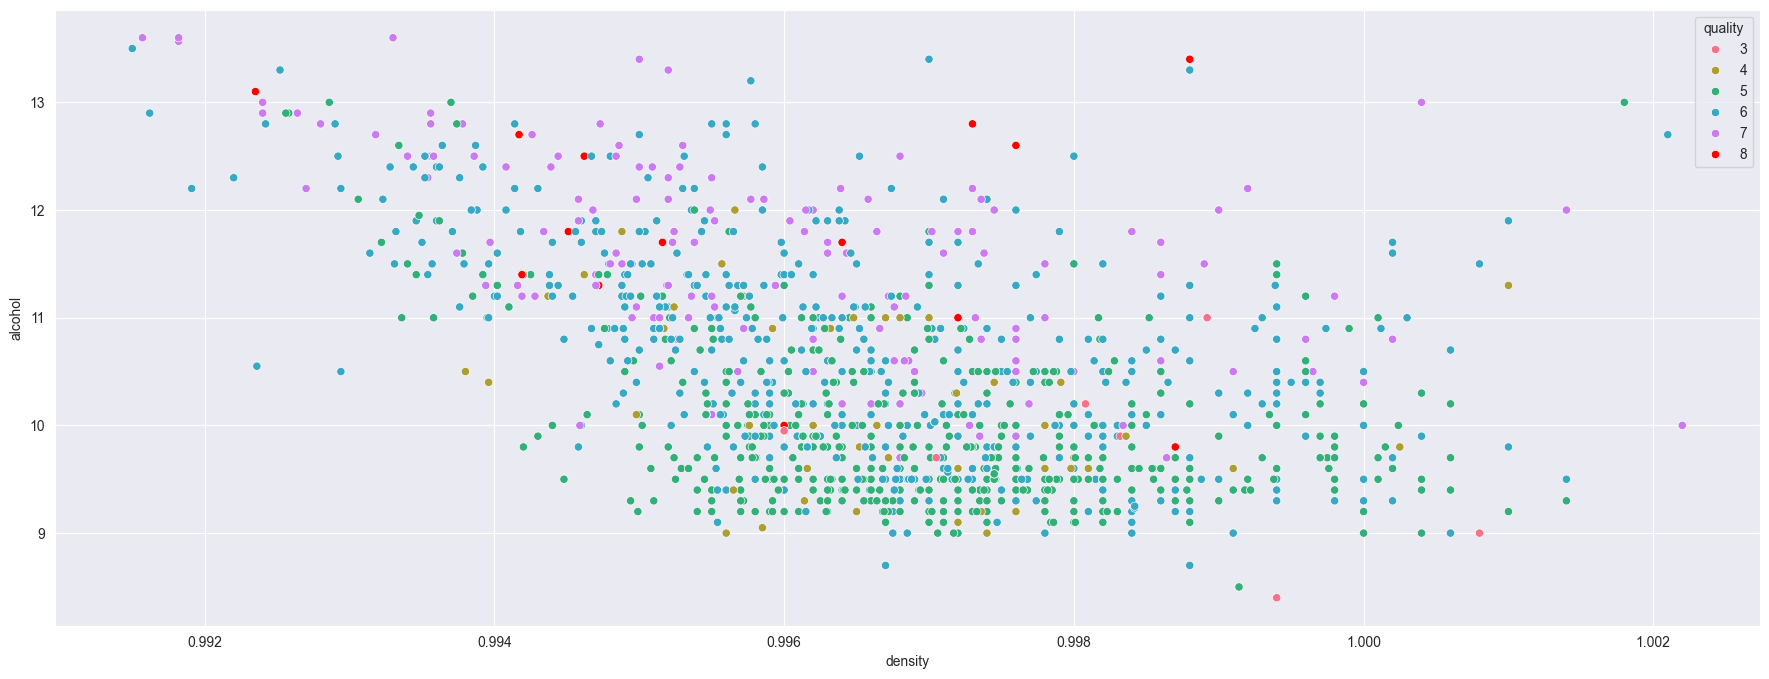

In [864]:
vibrant_palette = sns.color_palette("husl", n_colors=len(redwine_df['quality'].unique()) - 1)

# assigning red to category 8
custom_palette = {8: 'red'}
unique_qualities = sorted(redwine_df['quality'].unique())

for idx, quality in enumerate(unique_qualities):
    if quality != 8:
        custom_palette[quality] = vibrant_palette[idx]

plt.figure(figsize=(22, 8))
sns.scatterplot(x='density', y='alcohol', data=redwine_df, hue='quality', palette=custom_palette)

plt.show()


# Interesting Correlations between different features:

1. **Fixed acidity and pH** have a strong negative correlation (-0.68), meaning that as fixed acidity increases, pH decreases.

2. **Alcohol and quality** have a moderately positive correlation (0.48), suggesting that higher alcohol content is associated with better quality.

3. **Free sulfur dioxide and total sulfur dioxide** have a high positive correlation (0.67), which makes sense since they are related chemically.

4. **Low or Negligible Correlations**: Some variables, like chlorides and citric acid, show almost no correlation (0.056), meaning they don’t have a significant linear relationship.


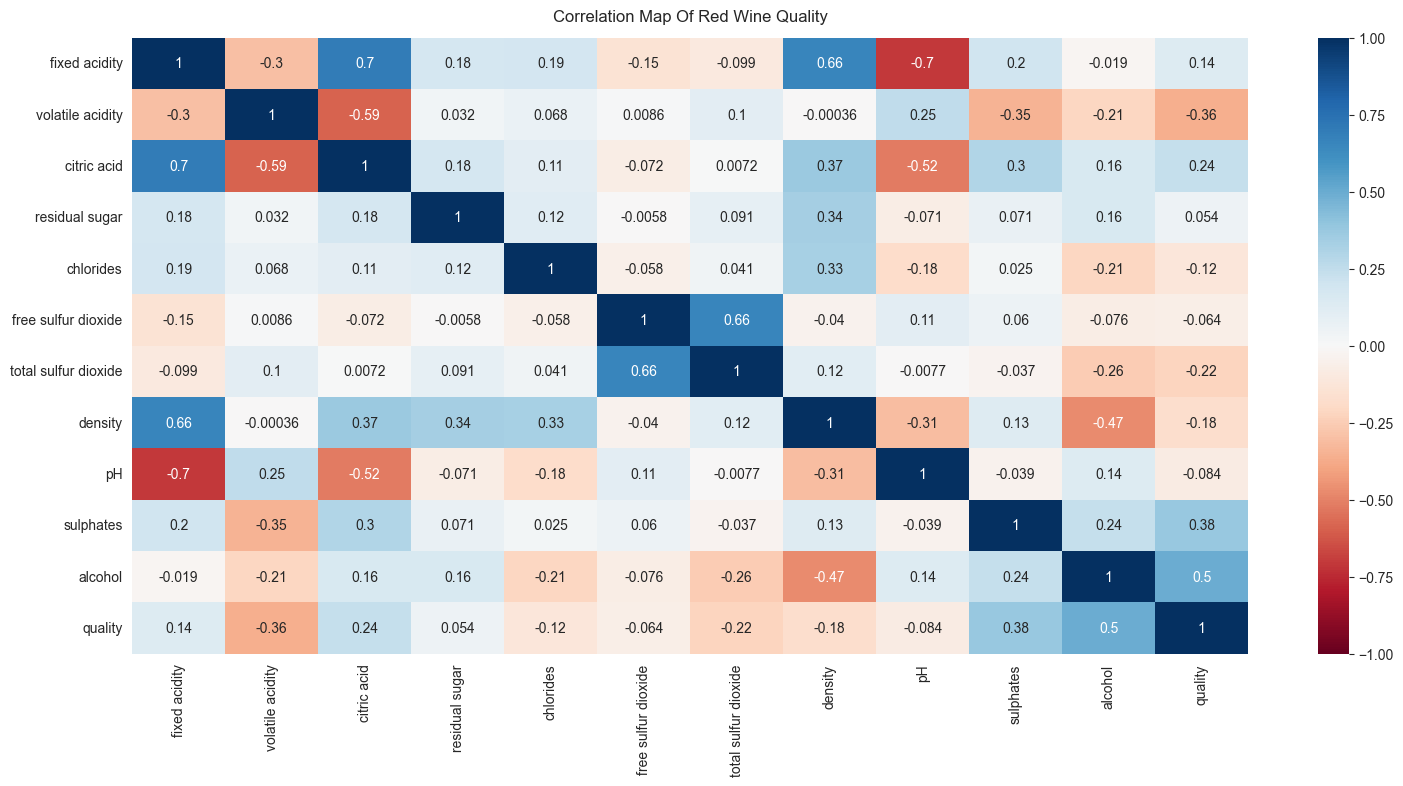

In [865]:
# making the heatmap with the 'RdBu' palette, which has red and blue tones
plt.figure(figsize=(18, 8))
sns.heatmap(redwine_df.corr(), vmin=-1, vmax=1, annot=True, cmap='RdBu')
plt.title('Correlation Map Of Red Wine Quality', fontdict={'fontsize':12}, pad=12)
plt.show()

# PreProcessing

**Checking for number of unique values in the dataset**

In [866]:
# checking how many unique qualities we have in the dataset
redwine_df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

**Checking the distribution of the target variable (quality)**

In [867]:
quality_counts = redwine_df['quality'].value_counts()
quality_counts

quality
5    617
6    586
7    185
4     47
8     16
3      7
Name: count, dtype: int64

**inspecting a sample of the dataset**

In [868]:
redwine_df.sample(6)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
220,9.4,0.340,0.37,2.2,0.075,5.0,13.0,0.99800,3.22,0.62,9.2,5
1176,8.2,0.635,0.10,2.1,0.073,25.0,60.0,0.99638,3.29,0.75,10.9,6
1019,6.5,0.580,0.00,2.2,0.096,3.0,13.0,0.99557,3.62,0.62,11.5,4
936,7.5,0.570,0.08,2.6,0.089,14.0,27.0,0.99592,3.30,0.59,10.4,6
964,10.2,0.290,0.65,2.4,0.075,6.0,17.0,0.99565,3.22,0.63,11.8,6
884,7.0,0.400,0.32,3.6,0.061,9.0,29.0,0.99416,3.28,0.49,11.3,7


**Splitting Data into dependant and independent variables**

In [869]:
X = redwine_df.drop(['quality'], axis = 1)
y = redwine_df['quality']

In [870]:
X.shape

(1458, 11)

In [871]:
X.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [872]:
y.shape

(1458,)

## *Find Best K-Score for KNN*

In this code, the function **`find_best_k`** aims to find the **optimal number of neighbors (K)** for the **K-Nearest Neighbors (KNN)** algorithm. The goal is to test various values of **K** (within a specified range) to determine which one yields the highest accuracy on the test data. The function works by iterating over a range of **K values** (from `k_range[0]` to `k_range[1]`, stepping by `k_range[2]`), training a **KNN model** for each value of **K**, and evaluating its performance on both the training and testing datasets. It records the accuracy for both sets, compares them, and selects the **K value** that provides the highest accuracy on the testing data. This process helps identify the optimal K, which balances underfitting and overfitting, ensuring the best generalization performance of the model. The function returns the best **K value**, its corresponding accuracy score, and the lists of training and testing accuracy scores for all tested K values.


In [873]:
def find_best_k(X_train, y_train, X_test, y_test, k_range=(1, 50, 1)):
    """
    Finds the best K value for KNeighborsClassifier using cross-validation and records training/testing accuracy.

    Parameters:
    X_train: Features for training the model
    y_train: Labels for training the model
    X_test: Features for testing the model
    y_test: Labels for testing the model
    k_range: A tuple (start, stop, step) representing the range of K values to test

    Returns:
    best_k: The K value that gives the highest cross-validated accuracy score
    best_score: The highest accuracy score
    training_accuracy: List of training accuracy scores for each K value
    testing_accuracy: List of testing accuracy scores for each K value
    """

    # extracting the range of K values to test
    k_values = range(k_range[0], k_range[1], k_range[2])

    # listing to hold the accuracy scores for each K value
    training_accuracy = []
    testing_accuracy = []
    
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        pipeline = Pipeline([('scaler', MinMaxScaler()), ('knn', knn)])
        
        pipeline.fit(X_train, y_train)
        
        y_train_pred = pipeline.predict(X_train)
        train_acc = accuracy_score(y_train, y_train_pred)
        training_accuracy.append(train_acc)
        
        # predicting on the testing data
        y_test_pred = pipeline.predict(X_test)
        test_acc = accuracy_score(y_test, y_test_pred)
        testing_accuracy.append(test_acc)
    
    # finding the best K value based on the test accuracy
    best_score = max(testing_accuracy)
    best_k = k_values[testing_accuracy.index(best_score)]

    print(f"Best K: {best_k} with test accuracy: {best_score:.4f}")
    
    return best_k, best_score, training_accuracy, testing_accuracy



Here’s a summary of each metric based on my data results from the k-best alogorithm below:

1. **Precision**: The model is more precise for class 5 and 6, but classes like 4 and 8 suffer from low precision, indicating some classes are predicted poorly.
2. **Recall**: Class 6 has the highest recall, meaning the model identifies this class more accurately, while classes 4 and 8 have poor recall, missing most actual instances.
3. **F1-Score**: Classes 5 and 6 perform relatively well with balanced F1-scores, but class 8 has a very low F1-score, indicating poor overall performance in that class.
4. **Support**: Classes 5 and 6 have the most samples, which could be why they perform better, while classes like 3 and 8 have very few samples, making their results unreliable.
5. **Accuracy**: The overall accuracy is 68.72%, showing that while the model performs decently, it struggles with minority classes.
6. **Macro Avg**: The low macro average values (especially recall) indicate that the model performs poorly on less frequent classes, significantly affecting overall performance.
7. **Weighted Avg**: This score reflects the model's performance across all classes, weighted by their occurrence, with a result of 69%, meaning the model's predictions are acceptable but not optimal.

Best K: 9 with test accuracy: 0.6152


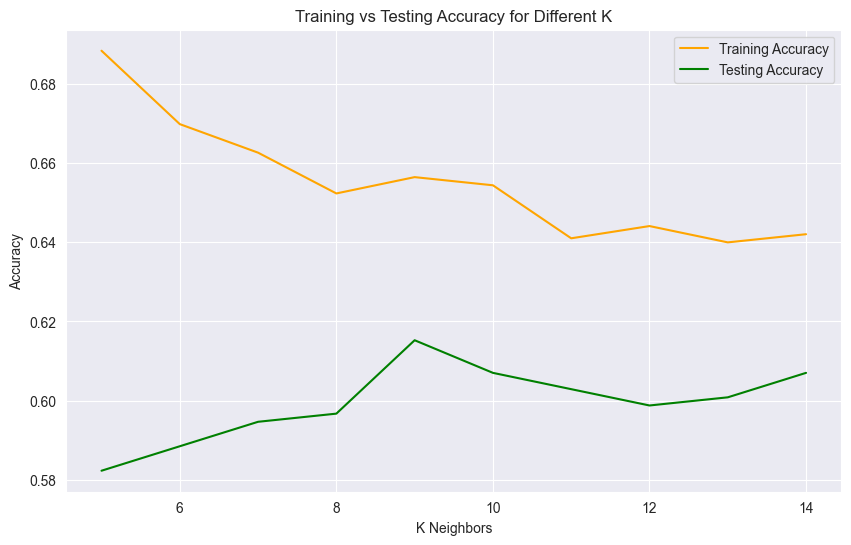

Test Accuracy with K=9 and Ball Tree: 0.6872
Classification Report:
              precision    recall  f1-score   support

           3       1.00      0.00      0.00         2
           4       0.00      0.00      0.00        10
           5       0.76      0.76      0.76       195
           6       0.66      0.72      0.69       210
           7       0.58      0.54      0.56        61
           8       1.00      0.12      0.22         8

    accuracy                           0.69       486
   macro avg       0.67      0.36      0.37       486
weighted avg       0.68      0.69      0.68       486



In [883]:
# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.333, random_state=42)

# Finding the best K value using cross-validation on the resampled (balanced) training data
best_k, best_score, training_accuracy, testing_accuracy = find_best_k(X_train, y_train, X_test, y_test, k_range=(5, 15, 1))

# Plot training vs testing accuracy for different K values with custom colors
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(5, 15), y=training_accuracy, label="Training Accuracy", color='orange')
sns.lineplot(x=range(5, 15), y=testing_accuracy, label="Testing Accuracy", color='green')
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy for Different K")
plt.legend()
plt.show()


# Using the best K value (from find_best_k function) in your KNN model
knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance', algorithm='ball_tree')

# A pipeline that scales the data and applies the KNN classifier
pipe_knn = Pipeline([('scale', MinMaxScaler()), ('knn', knn)])

# Fitting the model to the resampled training data
pipe_knn.fit(X_train, y_train)

# Making predictions on the test set
y_pred = pipe_knn.predict(X_test)

# Evaluation of the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with K={best_k} and Ball Tree: {accuracy:.4f}")

# Handling the precision issue with zero_division
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=1))


# Modeling with KNN pipeline for scaling the data and applying the KNN classifier

### Goal of the Scaler (MinMaxScaler):

The **goal of the scaler** in this pipeline is to normalize the feature values so that they fall within a specific range, typically between 0 and 1. The **MinMaxScaler** adjusts each feature by subtracting the minimum value and dividing by the range (max - min). This transformation is crucial for algorithms like **K-Nearest Neighbors (KNN)**, which rely on distance calculations between data points. 

Without scaling, features with larger ranges (e.g., a feature measured in thousands) could disproportionately influence the distance metric and dominate the model’s decision-making process. By scaling all features to the same range, the **MinMaxScaler** ensures that no feature is unfairly prioritized, leading to more balanced and meaningful distance calculations.


In [875]:
# making a KNN model using the best K (K=9)
knn = KNeighborsClassifier(n_neighbors=9)

# a pipeline to scale the data and apply the KNN classifier
pipe_knn = Pipeline([('scaler', MinMaxScaler()), ('knn', knn)])

# Fit the model to the training data
pipe_knn.fit(X_train, y_train)


Pipeline(steps=[('scaler', MinMaxScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=9))])

*Define Model Using Best K-Score*

In [876]:
# Predict on the test set
y_pred = pipe_knn.predict(X_test)
y_pred


array([5, 5, 6, 6, 6, 6, 6, 7, 5, 6, 5, 5, 5, 5, 6, 7, 6, 5, 6, 5, 7, 6,
       5, 6, 6, 5, 5, 5, 6, 7, 6, 5, 5, 5, 6, 6, 5, 6, 6, 5, 5, 5, 5, 5,
       5, 5, 6, 5, 6, 6, 5, 6, 6, 6, 5, 5, 5, 7, 6, 5, 4, 7, 5, 5, 5, 5,
       6, 5, 6, 5, 6, 6, 6, 5, 5, 6, 5, 5, 6, 6, 5, 6, 6, 6, 6, 6, 5, 6,
       7, 6, 5, 5, 6, 5, 6, 6, 6, 5, 5, 6, 5, 6, 5, 6, 6, 6, 5, 5, 6, 5,
       6, 6, 5, 6, 5, 5, 6, 6, 6, 6, 5, 5, 5, 6, 7, 5, 6, 6, 6, 5, 7, 6,
       5, 6, 6, 5, 7, 5, 5, 7, 6, 5, 5, 5, 6, 6, 6, 6, 6, 5, 6, 5, 5, 5,
       5, 6, 6, 6, 5, 5, 5, 6, 7, 7, 7, 5, 6, 6, 5, 6, 6, 5, 6, 5, 6, 5,
       6, 5, 6, 5, 6, 6, 5, 5, 7, 6, 5, 5, 6, 5, 5, 5, 7, 5, 6, 5, 6, 5,
       6, 6, 6, 5, 7, 7, 5, 6, 6, 6, 6, 6, 5, 5, 5, 6, 5, 6, 5, 6, 5, 7,
       7, 5, 5, 6, 7, 5, 6, 5, 6, 7, 5, 6, 5, 6, 6, 7, 6, 5, 5, 5, 5, 5,
       6, 6, 5, 5, 5, 6, 5, 5, 6, 6, 5, 5, 5, 5, 5, 6, 6, 5, 7, 5, 6, 6,
       5, 6, 5, 6, 7, 5, 6, 6, 6, 5, 5, 5, 6, 6, 5, 6, 6, 5, 6, 6, 6, 6,
       5, 5, 5, 5, 5, 7, 6, 6, 6, 5, 5, 5, 5, 6, 5,

### Key Metrics:
The classification report contains several important evaluation metrics for a classification problem:

1. **Precision**:
   - Precision is the ratio of correctly predicted positive observations to the total predicted positives (true positives / (true positives + false positives)).
   - A **higher precision** means fewer false positives.
   
2. **Recall**:
   - Recall is the ratio of correctly predicted positive observations to all observations in the actual class (true positives / (true positives + false negatives)).
   - A **higher recall** means fewer false negatives.

3. **F1-Score**:
   - The F1-Score is the harmonic mean of precision and recall. It gives a balanced score that considers both precision and recall.
   - F1-Score is useful when you need to balance precision and recall, especially in imbalanced datasets.
   
4. **Support**:
   - Support is the number of actual occurrences of each class in the dataset. It helps to understand how many samples belong to each class.

---

### Breakdown of the Classification Report:

| Label | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 3     | 1.00      | 0.00   | 0.00     | 2       |
| 4     | 0.00      | 0.00   | 0.00     | 10      |
| 5     | 0.66      | 0.75   | 0.70     | 195     |
| 6     | 0.60      | 0.62   | 0.61     | 210     |
| 7     | 0.48      | 0.38   | 0.42     | 61      |
| 8     | 1.00      | 0.00   | 0.00     | 8       |

---

### Observations:
1. **Class 3 and Class 8**:
   - **Precision** is 1.00, meaning when the model predicts class 3 or 8, it is correct. However, **recall** is 0.00, which means the model is not identifying any actual samples of these classes (likely because there are very few samples for these classes: only 2 and 8 respectively). This leads to an **F1-Score** of 0.00.
   
2. **Class 4**:
   - The model has **0.00 precision, recall, and F1-Score** for this class, indicating that the model either did not predict class 4 correctly at all or failed to recognize this class during classification.
   
3. **Class 5 and Class 6**:
   - These are the most frequent classes in the dataset. For class 5, the model achieves a **precision of 0.66** and **recall of 0.75**, which results in an **F1-Score of 0.70**.
   - Similarly, for class 6, the **precision is 0.60**, **recall is 0.62**, and **F1-Score is 0.61**. These scores are relatively decent compared to the other classes, indicating the model is performing better on the more frequent classes.
   
4. **Class 7**:
   - The model struggles with class 7, achieving only **0.48 precision** and **0.38 recall**, resulting in a relatively low **F1-Score of 0.42**.

---

### Overall Metrics:
- **Accuracy**:
  - The overall accuracy is **0.62**, meaning 62% of the predictions are correct. This is the ratio of correctly predicted instances to the total instances.
  
- **Macro Average**:
  - The **macro average** computes the unweighted average across all classes. It gives equal weight to all classes, regardless of their frequency. Here, the **macro avg precision, recall, and F1-Score** are low because the model struggles with the rare classes (like 3, 4, and 8).
  
- **Weighted Average**:
  - The **weighted average** computes the average across all classes, weighted by the number of instances in each class. It accounts for the imbalance in the dataset. Here, the **weighted avg F1-Score is 0.60**, meaning that the model’s performance is somewhat balanced, but it still struggles with certain classes.

---

### Conclusions:
- The model performs reasonably well for the frequent classes (5 and 6) but struggles with rare classes (3, 4, and 8).
- There is a class imbalance, which may be affecting the model’s performance.
- The low recall for some classes indicates the model is missing out on true positives for those classes, likely due to the dataset imbalance.

*Cross Validation*

In [877]:

# Calculate classification report with zero_division parameter
print(classification_report(y_test, y_pred, zero_division=1))


              precision    recall  f1-score   support

           3       1.00      0.00      0.00         2
           4       0.00      0.00      0.00        10
           5       0.66      0.75      0.70       195
           6       0.60      0.62      0.61       210
           7       0.48      0.38      0.42        61
           8       1.00      0.00      0.00         8

    accuracy                           0.62       486
   macro avg       0.62      0.29      0.29       486
weighted avg       0.61      0.62      0.60       486



Now, see if the HyperParameter Tuning process can boost until getting the maximum score.

In [878]:


# Perform cross-validation on the training set (with 5 folds)
cv_scores = cross_val_score(pipe_knn, X_train, y_train, cv=5) # number of folds for K fold cross-validation 5 in this case for now

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")


Cross-Validation Scores: [0.63589744 0.55384615 0.57216495 0.56185567 0.58762887]
Mean CV Accuracy: 0.5823


# HyperParameter Tuning

In [879]:
# To get all parameters available for tuning in the pipeline
params = pipe_knn.get_params()

# Print the list of all parameters
for param in params:
    print(param)


memory
steps
verbose
scaler
knn
scaler__clip
scaler__copy
scaler__feature_range
knn__algorithm
knn__leaf_size
knn__metric
knn__metric_params
knn__n_jobs
knn__n_neighbors
knn__p
knn__weights


In [880]:


# Impute missing values (if any) using the mean
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)

# Define the parameter grid
param_grid = {
    'knn__weights': ['uniform', 'distance'],
    'knn__leaf_size': [5, 10, 15, 20, 30, 40]
}

# Perform GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(pipe_knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


Best parameters: {'knn__leaf_size': 5, 'knn__weights': 'distance'}
Best cross-validation score: 0.6429


# applying the result of the hyper parameter tuning to the model

##### as you can see from the hyperparameter tunning section the accuracy has improved from 0.58 to 0.64 after hyper parameter tuning

In [881]:
# Update the KNN classifier in the existing pipeline with the best hyperparameters
pipe_knn.set_params(knn__leaf_size=5, knn__weights='distance')

# Fit the updated pipeline to the training data
pipe_knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_best = pipe_knn.predict(X_test)

# Evaluate the updated model's performance
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Test Accuracy with Tuned KNN: {accuracy_best:.4f}")

Test Accuracy with Tuned KNN: 0.6872


C:\Program Files\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


# Bagging + Tunning the parameters

1. When using an existing model in bagging, the **hyperparameters** of the base model remain unchanged; they are not reset or modified during the bagging process.  
2. **Bagging** involves re-training the model multiple times on different bootstrapped subsets of the data, but it uses the **same hyperparameters** that were initially set.  
3. Each instance of the model in bagging is **fitted independently** on a different subset, ensuring that the hyperparameters you tuned are consistently applied across all instances.  
4. The **hyperparameters** of the model are preserved and **not re-tuned** by bagging, as the process focuses on improving performance through resampling, not parameter optimization.  
5. There is **no need to re-tune or adjust hyperparameters** when applying bagging, since bagging only enhances the model’s robustness by training multiple instances on different data, all using the same pre-tuned configuration.


In [882]:


# Bagging classifier with KNN as the base estimator
bagging_model = BaggingClassifier(estimator=pipe_knn,
                                  n_estimators=30,
                                  random_state=42,
                                  n_jobs=-1) # applying bagging to the model, hyper parameters are tuned already

# Fit the bagging model to the original training data
bagging_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = bagging_model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with Bagging: {accuracy:.4f}")

# Display detailed performance metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy with Bagging: 0.6872
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        10
           5       0.75      0.77      0.76       195
           6       0.66      0.72      0.69       210
           7       0.54      0.51      0.53        61
           8       1.00      0.12      0.22         8

    accuracy                           0.69       486
   macro avg       0.49      0.35      0.37       486
weighted avg       0.67      0.69      0.67       486



C:\Program Files\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but BaggingClassifier was fitted without feature names
  warnings.warn(
C:\Program Files\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Program Files\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Program Files\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted 